In [5]:
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
mainPath = os.path.abspath(os.path.join(os.getcwd(), '..'))
if mainPath not in sys.path:
    sys.path.insert(0, mainPath)
from building_physics import Zone
import supply_system
import emission_system
from radiation import Location
from radiation import Window
ElectricityOut = []
HeatingDemand  = []  # Energy required by the zone
HeatingEnergy  = []  # Energy required by the supply system to provide HeatingDemand
CoolingDemand  = []  # Energy surplus of the zone
CoolingEnergy  = []  # Energy required by the supply system to get rid of CoolingDemand
IndoorAir      = []
OutsideTemp    = []
SolarGains     = []
COP            = []

In [6]:
GEOMETRY = {
    "window_south": 1501.29,
    "walls_opaque": 5168.52,
    "floor": 9474.68,
    "space": 37738.76
}

Office = Zone(
    window_area                       = GEOMETRY["window_south"],
    walls_area                        = GEOMETRY["walls_opaque"],
    floor_area                        = GEOMETRY["floor"],
    room_vol                          = GEOMETRY["space"],
    total_internal_area               = GEOMETRY["floor"]*3.5,
    thermal_capacitance_per_floor_area= 165000,
    u_walls                           = 0.19,
    u_windows                         = 1.41,
    ach_vent                          = 1.21,
    ach_infl                          = 0.41,
    lighting_load                     = 4.25,
    t_set_heating                     = 21.0,
    t_set_cooling                     = 28.0,
    ventilation_efficiency            = 0.5,
    max_cooling_energy_per_floor_area = -np.inf,
    max_heating_energy_per_floor_area = np.inf,
    heating_supply_system             = supply_system.DirectHeater,
    cooling_supply_system             = supply_system.DirectCooler,
    heating_emission_system           = emission_system.AirConditioning,
    cooling_emission_system           = emission_system.AirConditioning,
)

SouthWindow = Window(
    azimuth_tilt=0,
    alititude_tilt=90,
    glass_solar_transmittance=0.7,
    glass_light_transmittance=0.8,
    area=GEOMETRY["window_south"],
)

# Climate conditions
epw_path         = "../../../epw/ED-TMYx.2023.epw"
EDI           = Location(epwfile_path=epw_path)
year          = 2023
latitude_deg  = 55.95
longitude_deg = -3.37

# O&M conditions
t_m_prev         = 20
schedule_path    = os.path.join(mainPath, "auxiliary", "schedules_el_OFFICE.csv")
occupancyProfile = pd.read_csv(schedule_path)
gain_per_person  = 100
appliance_gains  = 11.77
max_occupancy    = 765

In [7]:
for hour in range(8760):

    occupancy = occupancyProfile.loc[hour, "People"] * max_occupancy
    internal_gains = occupancy * gain_per_person + appliance_gains * Office.floor_area

    t_out = EDI.weather_data["drybulb_C"][hour]

    altitude, azimuth = EDI.calc_sun_position(
        latitude_deg=latitude_deg,
        longitude_deg=longitude_deg,
        year=year,
        hoy=hour
    )
    
    SouthWindow.calc_solar_gains(
        sun_altitude=altitude,
        sun_azimuth=azimuth,
        normal_direct_radiation=EDI.weather_data["dirnorrad_Whm2"][hour],
        horizontal_diffuse_radiation=EDI.weather_data["difhorrad_Whm2"][hour]
    )

    SouthWindow.calc_illuminance(
        sun_altitude=altitude,
        sun_azimuth=azimuth,
        normal_direct_illuminance=EDI.weather_data["dirnorillum_lux"][hour],
        horizontal_diffuse_illuminance=EDI.weather_data["difhorillum_lux"][hour]
    )

    Office.solve_energy(
        internal_gains=internal_gains,
        solar_gains=SouthWindow.solar_gains,
        t_out=t_out,
        t_m_prev=t_m_prev
    )

    Office.solve_lighting(
        illuminance=SouthWindow.transmitted_illuminance,
        occupancy=occupancy
    )

    # **** KEEP ****
    t_m_prev = Office.t_m_next 

    HeatingDemand_kWh_m2 = (Office.heating_demand / 1000.0) /  GEOMETRY["floor"]
    HeatingEnergy_kWh_m2 = (Office.heating_energy / 1000.0) /  GEOMETRY["floor"]
    CoolingDemand_kWh_m2 = (Office.cooling_demand / 1000.0) /  GEOMETRY["floor"]
    CoolingEnergy_kWh_m2 = (Office.cooling_energy / 1000.0) /  GEOMETRY["floor"]
    ElectricityOut_kWh_m2 = (Office.electricity_out / 1000.0) /  GEOMETRY["floor"]

    HeatingDemand.append(HeatingDemand_kWh_m2)
    HeatingEnergy.append(HeatingEnergy_kWh_m2)
    CoolingDemand.append(CoolingDemand_kWh_m2)
    CoolingEnergy.append(CoolingEnergy_kWh_m2)
    ElectricityOut.append(ElectricityOut_kWh_m2)

    IndoorAir.append(Office.t_air)
    OutsideTemp.append(t_out)
    SolarGains.append(SouthWindow.solar_gains)
    COP.append(Office.cop)

# Output

In [8]:
annualResults = pd.DataFrame({
    "HeatingDemand": HeatingDemand,
    "HeatingEnergy": HeatingEnergy,
    "CoolingDemand": CoolingDemand,
    "CoolingEnergy": CoolingEnergy,
    "IndoorAir": IndoorAir,
    "OutsideTemp": OutsideTemp,
    "SolarGains": SolarGains,
    "COP": COP
})

annual_EUI = annualResults[["HeatingEnergy", "CoolingEnergy"]].sum()

annualResults.index = pd.date_range("2023-01-01", periods=8760, freq="h")
monthly_EUI = (
    annualResults[["HeatingEnergy", "CoolingEnergy"]]
    .resample("ME")
    .sum()
)

print("Annual EUI (kWh/m²·yr)")
print(annual_EUI)
monthly_EUI

Annual EUI (kWh/m²·yr)
HeatingEnergy    26.864356
CoolingEnergy    10.038071
dtype: float64


,HeatingEnergy,CoolingEnergy
2023-01-31,5.837607,0.000000
2023-02-28,4.257476,0.000000
2023-03-31,3.904846,0.011113
2023-04-30,1.291091,0.148163
2023-05-31,0.172010,0.641812
2023-06-30,0.000000,3.092832
2023-07-31,0.000000,1.092191
2023-08-31,0.000000,1.980024
2023-09-30,0.000000,2.946618
2023-10-31,0.998749,0.125318


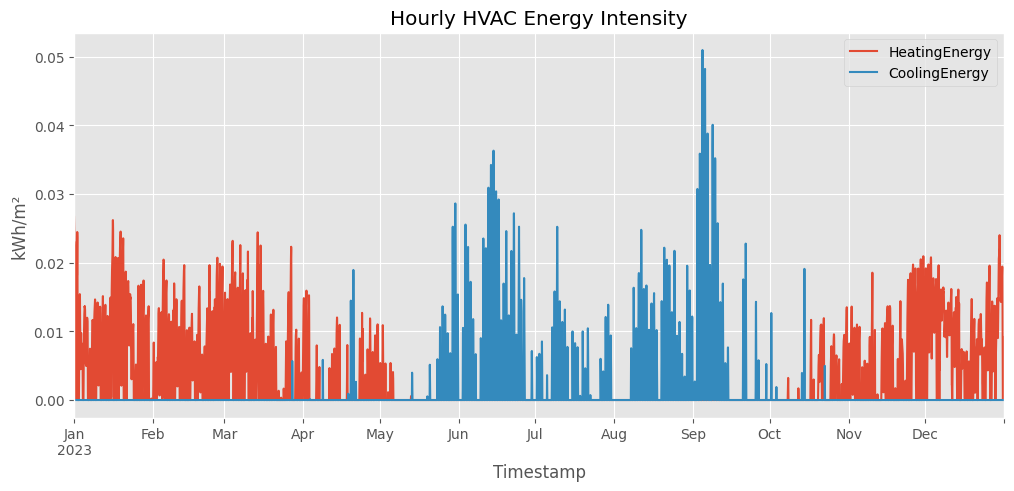

In [9]:
plt.style.use("ggplot")
ax = annualResults[["HeatingEnergy", "CoolingEnergy"]].plot(figsize=(12,5))
ax.minorticks_off()

plt.ylabel("kWh/m²")
plt.xlabel("Timestamp")
plt.title("Hourly HVAC Energy Intensity")
plt.show()

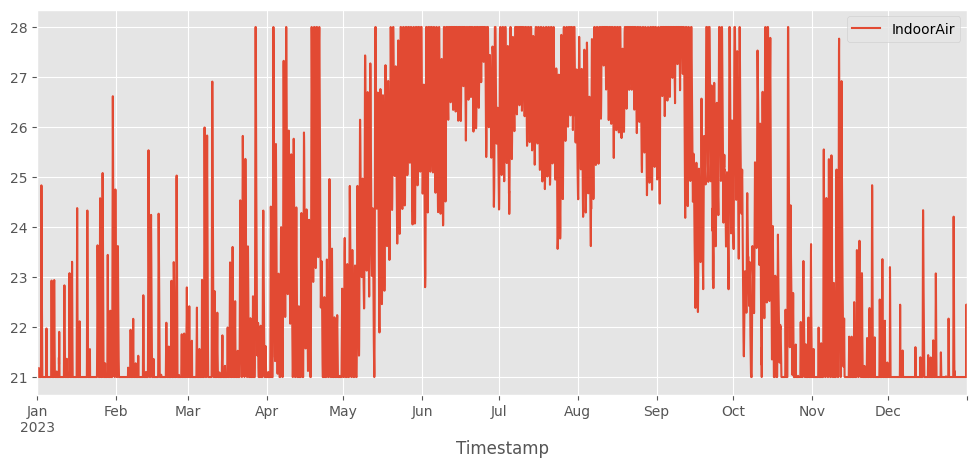

In [10]:
ax = annualResults[["IndoorAir"]].plot(figsize=(12,5))
ax.minorticks_off()

plt.ylabel("")
plt.xlabel("Timestamp")
plt.title("")
plt.show()